# Volumes sous-corticaux après JDAC et ses variantes

Ce notebook répond à trois questions :

1. Les traitements modifient-ils le `run-01` alors qu'il n'y a presque aucun mouvement à corriger ?
2. Les scans bougés se rapprochent-ils du `raw/run-01` du même sujet ?
3. Le volume mesuré reste-t-il associé au score Agitation ?

Les mesures sont des **volumes en mm³** extraits de `aseg.stats`. Le `raw/run-01` est une référence opérationnelle, pas une vérité anatomique parfaite.

Trois précautions de lecture, décidées après une première version illisible :

- **Mesures de qualité séparées.** Les trous de surface (`SurfaceHoles`), les hypointensités et les ratios `-to-eTIV` ne sont pas des volumes anatomiques et ont une base quasi nulle. Exprimés en pourcentage ils explosaient et masquaient le signal réel. Ils sont analysés à part, en unités natives.
- **Structures dégénérées retirées.** Toute mesure dont le volume médian sur `raw/run-01` est nul (`5th-Ventricle`, `vessel`, `choroid-plexus`, `Optic-Chiasm`, hypointensités latéralisées) est écartée : aucune variation exploitable.
- **Pourcentages robustes.** La variation relative est le ratio des médianes (médiane des Δ sur médiane de la base), pas la médiane des rapports, pour éviter qu'un sujet à volume proche de zéro fasse diverger le pourcentage. Une normalisation par l'eTIV du sujet complète la lecture.

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
warnings.filterwarnings("ignore")

CONDITIONS = ["brut", "preproc", "jdac", "jdac_antiartonly", "jdac_nodenoise"]
SHORT = {"brut":"brut", "preproc":"prep", "jdac":"jdac",
         "jdac_antiartonly":"aa×1", "jdac_nodenoise":"aa×4"}
REPO = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "results/ds004332").exists()), Path.home() / "Documents/GitHub/jdac-motion-correction")
ASEG_DIR = Path.home() / "Documents/derivatives/ds004332/aseg_stats"
ASEG_FILES = {
    "brut": "aseg_brut.csv",
    "preproc": "aseg_preproc.csv",
    "jdac": "aseg_jdac.csv",
    "jdac_antiartonly": "aseg_antiartonly.csv",
    "jdac_nodenoise": "aseg_nodenoise.csv",
}
AGIT = REPO / "results/ds004332/agitation/ds004332_agitation_clinica.csv"

missing = [str(ASEG_DIR / name) for name in ASEG_FILES.values()
           if not (ASEG_DIR / name).is_file()]
if missing:
    raise FileNotFoundError("Tables aseg absentes :\n" + "\n".join(missing))

def load_aseg_table(condition, filename):
    # Les fichiers portent l'extension .csv mais sont séparés par tabulations.
    wide = pd.read_csv(ASEG_DIR / filename, sep="	")
    id_col = "Measure:volume" if "Measure:volume" in wide.columns else wide.columns[0]
    identifiers = wide[id_col].astype(str).str.extract(
        r"(sub-[^_/\s]+)_(run-\d+)", expand=True
    )
    if identifiers.isna().any().any():
        bad = wide.loc[identifiers.isna().any(axis=1), id_col].head().tolist()
        raise ValueError(f"Identifiants sujet/run non reconnus dans {filename}: {bad}")
    long = wide.drop(columns=id_col).assign(
        subject=identifiers[0].values,
        run=identifiers[1].values,
    ).melt(id_vars=["subject", "run"], var_name="measure", value_name="value_mm3")
    long["condition"] = condition
    long["source_file"] = str(ASEG_DIR / filename)
    return long

d = pd.concat(
    [load_aseg_table(condition, filename)
     for condition, filename in ASEG_FILES.items()],
    ignore_index=True,
)
d["value_mm3"] = pd.to_numeric(d["value_mm3"], errors="coerce")
d["condition"] = pd.Categorical(d["condition"], CONDITIONS, ordered=True)
agit = pd.read_csv(AGIT).rename(columns={"sub":"subject", "condition":"run", "motion":"agitation"})
d = d.merge(agit[["subject", "run", "agitation"]], on=["subject", "run"], how="left")
print(f"Dossier source : {ASEG_DIR}")
print(f"{len(d):,} mesures | {d['measure'].nunique()} colonnes | {d[['subject','run','condition']].drop_duplicates().shape[0]} acquisitions")

Dossier source : /home/av62870@ens.ad.etsmtl.ca/Documents/derivatives/ds004332/aseg_stats
21,125 mesures | 65 colonnes | 325 acquisitions


## Classification des mesures

Chaque colonne de `aseg.stats` est rangée dans une catégorie avant toute analyse :

- **Volumes anatomiques** (globaux et régionaux) : seuls concernés par les variations en % ;
- **Mesures de qualité** : trous de surface, hypointensités, ratios `-to-eTIV`, analysées à part ;
- **Dégénérées** : volume médian nul sur `raw/run-01`, retirées.

L'eTIV du `raw/run-01` de chaque sujet sert de normalisateur commun.

In [2]:
ETIV_NAME = "EstimatedTotalIntraCranialVol"
QC_MEASURES = {"SurfaceHoles", "lhSurfaceHoles", "rhSurfaceHoles", "WM-hypointensities"}
RATIO_MEASURES = {"BrainSegVol-to-eTIV", "MaskVol-to-eTIV"}
GLOBAL_MEASURES = {
    "BrainSegVol", "BrainSegVolNotVent", "lhCortexVol", "rhCortexVol", "CortexVol",
    "lhCerebralWhiteMatterVol", "rhCerebralWhiteMatterVol", "CerebralWhiteMatterVol",
    "SubCortGrayVol", "TotalGrayVol", "SupraTentorialVol", "SupraTentorialVolNotVent",
    "MaskVol", ETIV_NAME,
}
MIN_SIZE_MM3 = 100.0   # seuil sous lequel une base est jugée trop petite / dégénérée

# base = volume médian sur le scan de référence (brut, run-01)
baseline = (d[(d["condition"]=="brut") & (d["run"]=="run-01")]
            .groupby("measure")["value_mm3"].median())

# Les mesures de qualité (trous, hypointensités, ratios) restent en catégorie QC
# quelle que soit leur base : le seuil de taille ne trie que les vrais volumes.
NON_ANAT = QC_MEASURES | RATIO_MEASURES | {ETIV_NAME}
qc = sorted((QC_MEASURES | RATIO_MEASURES) & set(baseline.index))
degenerate = sorted([m for m in baseline.index
                     if m not in NON_ANAT and baseline[m] <= MIN_SIZE_MM3])
anat = [m for m in baseline.index
        if m not in NON_ANAT and baseline[m] > MIN_SIZE_MM3]
anat_global = [m for m in anat if m in GLOBAL_MEASURES]
anat_regional = [m for m in anat if m not in GLOBAL_MEASURES]

# eTIV de référence par sujet (brut, run-01) pour normaliser les écarts
etiv_ref = (d[(d["condition"]=="brut") & (d["run"]=="run-01") & (d["measure"]==ETIV_NAME)]
            [["subject", "value_mm3"]].rename(columns={"value_mm3":"etiv_ref"}))
d = d.merge(etiv_ref, on="subject", how="left")

print(f"Volumes anatomiques : {len(anat)}  ({len(anat_global)} globaux, {len(anat_regional)} régionaux)")
print(f"Mesures de qualité analysées à part : {qc}")
print(f"Dégénérées retirées (base médiane ≤ {MIN_SIZE_MM3:.0f} mm³) : {degenerate}")
print(f"eTIV de référence disponible pour {etiv_ref['subject'].nunique()} sujets "
      f"(médiane {etiv_ref['etiv_ref'].median():,.0f} mm³)")

Volumes anatomiques : 46  (13 globaux, 33 régionaux)
Mesures de qualité analysées à part : ['BrainSegVol-to-eTIV', 'MaskVol-to-eTIV', 'SurfaceHoles', 'WM-hypointensities', 'lhSurfaceHoles', 'rhSurfaceHoles']
Dégénérées retirées (base médiane ≤ 100 mm³) : ['5th-Ventricle', 'Left-WM-hypointensities', 'Left-choroid-plexus', 'Left-non-WM-hypointensities', 'Left-vessel', 'Optic-Chiasm', 'Right-WM-hypointensities', 'Right-choroid-plexus', 'Right-non-WM-hypointensities', 'Right-vessel', 'SegmentedTotalIntracranialVol', 'non-WM-hypointensities']
eTIV de référence disponible pour 22 sujets (médiane 1,581,876 mm³)


## 0. Complétude et contrôle des données

Une acquisition n'est analysée que si son `aseg.stats` existe. Les valeurs manquantes, les doublons et l'eTIV sont contrôlés avant les modèles. Une variation de l'eTIV entre conditions révélerait déjà une instabilité de reconstruction.

In [3]:
qc_tab = pd.DataFrame({
    "n acquisitions": d.groupby("condition", observed=True).apply(
        lambda x: x[["subject","run"]].drop_duplicates().shape[0]),
    "n mesures": d.groupby("condition", observed=True)["measure"].nunique(),
    "valeurs manquantes": d.groupby("condition", observed=True)["value_mm3"].apply(lambda x: x.isna().sum()),
    "doublons": d.groupby("condition", observed=True).apply(
        lambda x: x.duplicated(["subject","run","measure"]).sum()),
})
display(qc_tab)
etiv = d[d["measure"]==ETIV_NAME]
if len(etiv):
    print("eTIV (mm³) par condition et run :")
    display(etiv.groupby(["condition","run"], observed=True)["value_mm3"].agg(["count","mean","std"]))

,n acquisitions,n mesures,valeurs manquantes,doublons
condition,,,,
brut,66,65,0,0
preproc,64,65,0,0
jdac,64,65,0,0
jdac_antiartonly,66,65,0,0
jdac_nodenoise,65,65,0,0


eTIV (mm³) par condition et run :


count          mean            std
condition        run                                       
brut             run-01     22  1.646358e+06  165431.095368
                 run-02     22  1.625233e+06  160325.505659
                 run-03     22  1.565963e+06  169739.898858
preproc          run-01     21  1.645934e+06  168813.949623
                 run-02     22  1.621479e+06  155821.911261
                 run-03     21  1.562512e+06  174196.813952
jdac             run-01     22  1.655678e+06  162441.605659
                 run-02     22  1.637787e+06  157878.702382
                 run-03     20  1.588528e+06  182976.682637
jdac_antiartonly run-01     22  1.647074e+06  164047.178786
                 run-02     22  1.628903e+06  157016.754719
                 run-03     22  1.570155e+06  172482.564363
jdac_nodenoise   run-01     21  1.628892e+06  140657.464020
                 run-02     22  1.639626e+06  154340.975109
                 run-03     22  1.588788e+06  173036.375551

## A. Effet propre du traitement sur le scan immobile

Pour chaque structure anatomique et chaque sujet, sur `run-01` :

Δ = V(condition) − V(brut)

Une différence non nulle indique que le traitement ou la reconstruction FreeSurfer modifie le volume mesuré sur la référence immobile. Le pourcentage est le **ratio des médianes** (médiane des Δ divisée par la médiane de la base), robuste aux dénominateurs proches de zéro. La colonne `delta_pct_etiv` rapporte le même Δ à l'eTIV du sujet, pour comparer des structures de tailles très différentes. Les tests sont appariés (Wilcoxon) et corrigés par FDR sur l'ensemble des structures et conditions.

Volumes GLOBAUX (cortex, matière blanche, volumes totaux) — variation vs brut sur run-01 :


,condition,measure,baseline_mm3,delta_median_mm3,delta_pct,delta_pct_etiv,p_fdr
91,jdac,rhCortexVol,258598.0,-36635.0,-14.17,-2.342,0.0000
90,jdac,rhCerebralWhiteMatterVol,230797.0,24930.0,10.80,1.563,0.0000
89,jdac,lhCortexVol,259513.0,-37046.0,-14.28,-2.360,0.0000
88,jdac,lhCerebralWhiteMatterVol,232250.0,25968.0,11.18,1.539,0.0000
87,jdac,TotalGrayVol,700304.0,-75915.0,-10.84,-4.827,0.0000
86,jdac,SupraTentorialVolNotVent,1014182.0,-34750.0,-3.43,-2.244,0.0000
85,jdac,SupraTentorialVol,1320220.0,-5068.0,-0.38,-0.334,0.5009
71,jdac,MaskVol,1543394.0,-9342.0,-0.61,-0.556,0.0723
58,jdac,CortexVol,518111.0,-73694.0,-14.22,-4.670,0.0000
57,jdac,CerebralWhiteMatterVol,463047.0,50708.0,10.95,3.111,0.0000



Structures RÉGIONALES les plus modifiées (|%| décroissant) :


,condition,measure,baseline_mm3,delta_median_mm3,delta_pct,p_fdr
157,jdac_nodenoise,Left-Inf-Lat-Vent,544.0,141.0,25.92,0.0000
170,jdac_nodenoise,Right-Inf-Lat-Vent,526.0,111.0,21.10,0.0000
76,jdac,Right-Cerebellum-White-Matter,15650.0,2386.0,15.25,0.0000
65,jdac,Left-Inf-Lat-Vent,558.0,80.0,14.43,0.0001
63,jdac,Left-Cerebellum-White-Matter,15801.0,2206.0,13.96,0.0000
160,jdac_nodenoise,Left-Putamen,5878.0,-751.0,-12.78,0.0000
74,jdac,Right-Caudate,4294.0,-547.0,-12.74,0.0000
144,jdac_nodenoise,CC_Central,782.0,-88.0,-11.30,0.1400
173,jdac_nodenoise,Right-Putamen,5580.0,-614.0,-11.01,0.0000
59,jdac,Left-Accumbens-area,680.0,-72.0,-10.59,0.0001


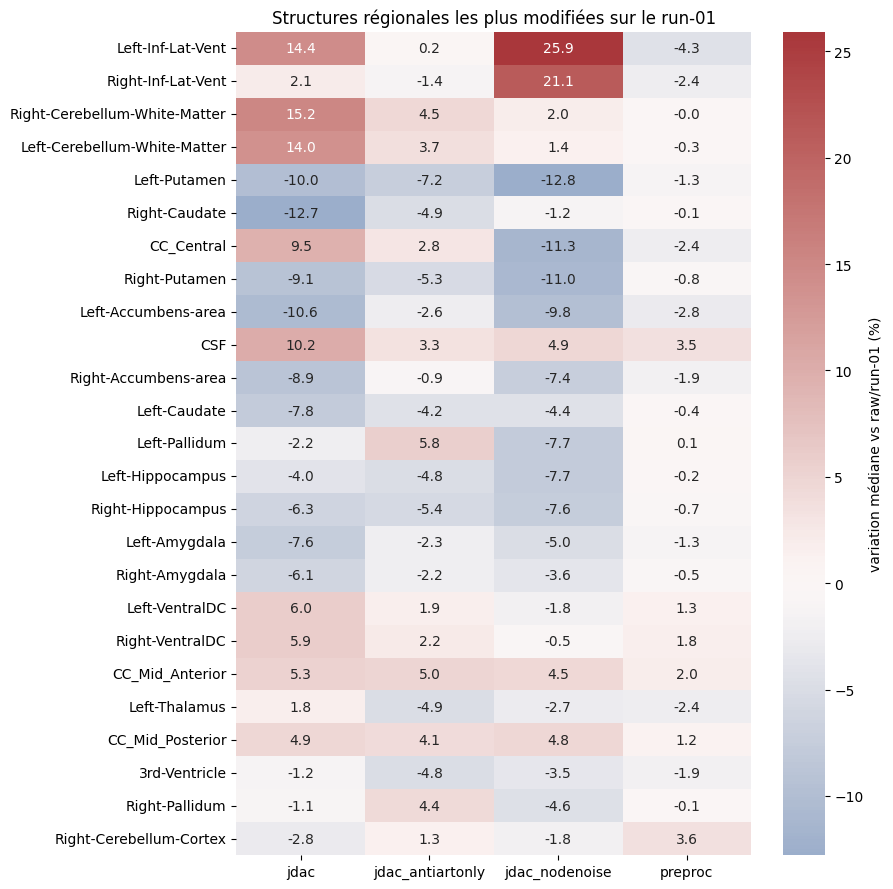

In [4]:
wide01 = d[d["run"]=="run-01"].pivot_table(
    index=["subject","measure"], columns="condition", values="value_mm3", observed=True)
etiv01 = d[d["run"]=="run-01"].drop_duplicates("subject").set_index("subject")["etiv_ref"]
rows = []
for condition in CONDITIONS[1:]:
    pairs = wide01[["brut", condition]].dropna()
    for measure, x in pairs.groupby(level="measure"):
        if measure not in anat:
            continue
        delta = x[condition] - x["brut"]
        base = x["brut"].median()
        subj = x.index.get_level_values("subject")
        etiv_sub = etiv01.reindex(subj).values
        try:
            p = stats.wilcoxon(delta).pvalue if len(delta) >= 3 and np.any(delta != 0) else 1.0
        except ValueError:
            p = np.nan
        rows.append({"condition":condition, "measure":measure,
                     "groupe":"global" if measure in anat_global else "régional",
                     "n":len(delta), "baseline_mm3":base,
                     "delta_median_mm3":delta.median(),
                     "delta_pct":100*delta.median()/base,
                     "delta_pct_etiv":100*np.nanmedian(delta.values/etiv_sub), "p":p})
a = pd.DataFrame(rows)
valid = a["p"].notna()
a.loc[valid, "p_fdr"] = multipletests(a.loc[valid, "p"], method="fdr_bh")[1]

print("Volumes GLOBAUX (cortex, matière blanche, volumes totaux) — variation vs brut sur run-01 :")
display(a[a["groupe"]=="global"].sort_values("condition")
        .loc[:, ["condition","measure","baseline_mm3","delta_median_mm3","delta_pct","delta_pct_etiv","p_fdr"]]
        .round({"baseline_mm3":0,"delta_median_mm3":0,"delta_pct":2,"delta_pct_etiv":3,"p_fdr":4}))
print("\nStructures RÉGIONALES les plus modifiées (|%| décroissant) :")
display(a[a["groupe"]=="régional"].sort_values("delta_pct", key=abs, ascending=False)
        .loc[:, ["condition","measure","baseline_mm3","delta_median_mm3","delta_pct","p_fdr"]]
        .head(25).round({"baseline_mm3":0,"delta_median_mm3":0,"delta_pct":2,"p_fdr":4}))

heat = a[a["groupe"]=="régional"].pivot(index="measure", columns="condition", values="delta_pct")
top = heat.abs().max(axis=1).nlargest(25).index
plt.figure(figsize=(9, 9))
sns.heatmap(heat.loc[top], center=0, cmap="vlag", annot=True, fmt=".1f",
            cbar_kws={"label":"variation médiane vs raw/run-01 (%)"})
plt.title("Structures régionales les plus modifiées sur le run-01")
plt.xlabel(""); plt.ylabel("")
plt.tight_layout(); plt.show()

### A-bis. Mesures de qualité (hors volumes anatomiques)

Trous de surface, hypointensités et ratios `-to-eTIV` ont une base quasi nulle : un pourcentage y est trompeur. Ils sont donc lus en **variation absolue** (unités natives : nombre de trous, mm³ d'hypointensités, ratio sans unité). Un traitement qui crée des trous de surface ou des hypointensités dégrade la reconstruction sans que cela soit une correction du mouvement.

In [5]:
rows = []
for condition in CONDITIONS[1:]:
    pairs = wide01[["brut", condition]].dropna()
    for measure, x in pairs.groupby(level="measure"):
        if measure not in qc:
            continue
        delta = x[condition] - x["brut"]
        try:
            p = stats.wilcoxon(delta).pvalue if len(delta) >= 3 and np.any(delta != 0) else 1.0
        except ValueError:
            p = np.nan
        rows.append({"condition":condition, "measure":measure, "n":len(delta),
                     "brut_median":x["brut"].median(), "cond_median":x[condition].median(),
                     "delta_median":delta.median(), "p":p})
aq = pd.DataFrame(rows)
if len(aq):
    valid = aq["p"].notna()
    aq.loc[valid, "p_fdr"] = multipletests(aq.loc[valid, "p"], method="fdr_bh")[1]
    display(aq.sort_values(["measure","condition"]).round(3))

,condition,measure,n,brut_median,cond_median,delta_median,p,p_fdr
6,jdac,BrainSegVol-to-eTIV,22,0.917,0.915,-0.007,0.008,0.013
12,jdac_antiartonly,BrainSegVol-to-eTIV,22,0.917,0.912,-0.007,0.000,0.000
18,jdac_nodenoise,BrainSegVol-to-eTIV,21,0.917,0.918,-0.004,0.046,0.069
0,preproc,BrainSegVol-to-eTIV,21,0.917,0.917,-0.004,0.076,0.101
7,jdac,MaskVol-to-eTIV,22,0.970,0.955,-0.012,0.001,0.002
13,jdac_antiartonly,MaskVol-to-eTIV,22,0.970,0.952,-0.013,0.000,0.000
19,jdac_nodenoise,MaskVol-to-eTIV,21,0.970,0.945,-0.022,0.000,0.000
1,preproc,MaskVol-to-eTIV,21,0.970,0.963,-0.004,0.050,0.071
8,jdac,SurfaceHoles,22,22.500,22.500,1.500,0.709,0.775
14,jdac_antiartonly,SurfaceHoles,22,22.500,36.000,8.500,0.000,0.000


## B. Récupération des volumes des scans bougés

Pour chaque structure anatomique, le traitement est comparé au `raw/run-01` du même sujet :

G = |V(raw, run) − V(raw, run01)| − |V(condition, run) − V(raw, run01)|

- G > 0 : le traitement rapproche le volume de la référence ;
- G < 0 : il l'en éloigne.

Le gain médian est aussi exprimé en % de la base de la structure (`gain_pct`), pour que le classement ne soit plus dominé par les gros volumes totaux. La fraction de cas améliorés est déjà sans échelle.

In [6]:
ref = (d[(d["condition"]=="brut") & (d["run"]=="run-01")]
       [["subject","measure","value_mm3"]].rename(columns={"value_mm3":"reference_mm3"}))
moved = d[d["run"].isin(["run-02","run-03"]) & d["measure"].isin(anat)].merge(
    ref, on=["subject","measure"], how="inner")
moved["error_mm3"] = (moved["value_mm3"]-moved["reference_mm3"]).abs()
raw_error = (moved[moved["condition"]=="brut"]
             [["subject","run","measure","error_mm3"]].rename(columns={"error_mm3":"raw_error_mm3"}))
moved = moved.merge(raw_error, on=["subject","run","measure"], how="inner")
moved["gain_mm3"] = moved["raw_error_mm3"] - moved["error_mm3"]

summary_b = moved[moved["condition"]!="brut"].groupby("condition", observed=True).agg(
    n=("gain_mm3","size"), gain_median_mm3=("gain_mm3","median"),
    gain_mean_mm3=("gain_mm3","mean"), fraction_amelioree=("gain_mm3",lambda x:(x>0).mean()))
print("Bilan par condition (toutes structures anatomiques confondues) :")
display(summary_b.round({"gain_median_mm3":1,"gain_mean_mm3":1,"fraction_amelioree":3}))

base_ser = baseline.reindex(anat)
b = (moved[moved["condition"]!="brut"].groupby(["condition","measure"], observed=True)["gain_mm3"]
     .median().reset_index(name="gain_median_mm3"))
b["gain_pct"] = 100 * b["gain_median_mm3"] / b["measure"].map(base_ser)
print("\nStructures les mieux récupérées par condition (gain en % de la base) :")
display(b.sort_values("gain_pct", ascending=False).groupby("condition", observed=True).head(6)
        .round({"gain_median_mm3":1,"gain_pct":2}))
print("\nStructures les plus dégradées par condition :")
display(b.sort_values("gain_pct").groupby("condition", observed=True).head(6)
        .round({"gain_median_mm3":1,"gain_pct":2}))

Bilan par condition (toutes structures anatomiques confondues) :


,n,gain_median_mm3,gain_mean_mm3,fraction_amelioree
condition,,,,
preproc,1978,-6.2,1727.1,0.475
jdac,1932,-153.8,48.9,0.321
jdac_antiartonly,2024,-9.0,3074.1,0.471
jdac_nodenoise,2024,-22.5,8794.2,0.459



Structures les mieux récupérées par condition (gain en % de la base) :


,condition,measure,gain_median_mm3,gain_pct
181,jdac_nodenoise,lhCortexVol,18476.7,7.12
150,jdac_nodenoise,CortexVol,36824.2,7.11
183,jdac_nodenoise,rhCortexVol,17459.2,6.75
178,jdac_nodenoise,SupraTentorialVolNotVent,67532.5,6.66
142,jdac_nodenoise,BrainSegVolNotVent,64433.0,5.53
182,jdac_nodenoise,rhCerebralWhiteMatterVol,12279.2,5.32
85,jdac,SupraTentorialVol,51804.0,3.92
49,jdac,BrainSegVol,52492.5,3.60
134,jdac_antiartonly,lhCerebralWhiteMatterVol,8338.8,3.59
103,jdac_antiartonly,CerebralWhiteMatterVol,15337.0,3.31



Structures les plus dégradées par condition :


,condition,measure,gain_median_mm3,gain_pct
68,jdac,Left-Putamen,-1119.8,-19.05
81,jdac,Right-Putamen,-963.5,-17.16
160,jdac_nodenoise,Left-Putamen,-1001.3,-17.03
59,jdac,Left-Accumbens-area,-102.8,-15.10
151,jdac_nodenoise,Left-Accumbens-area,-99.6,-14.63
164,jdac_nodenoise,Right-Accumbens-area,-94.0,-13.87
173,jdac_nodenoise,Right-Putamen,-772.9,-13.76
159,jdac_nodenoise,Left-Pallidum,-240.2,-13.61
67,jdac,Left-Pallidum,-199.4,-11.30
72,jdac,Right-Accumbens-area,-73.4,-10.82


## C. Le mouvement prédit-il encore chaque volume ?

Pour chaque condition et chaque volume anatomique :

Volume ~ Agitation + (1 | sujet)

L'intercept aléatoire absorbe les différences stables de taille entre sujets. Le coefficient Agitation est exprimé en **mm³ par point Agitation**, et `coef_pct_par_point` le rapporte à la base de la structure pour comparer les effets. La correction FDR est appliquée séparément dans chaque condition, sur les modèles convergés.

In [7]:
rows = []
for condition in CONDITIONS:
    dc = d[(d["condition"]==condition) & d["measure"].isin(anat)].dropna(subset=["agitation","value_mm3"])
    for measure, x in dc.groupby("measure", observed=True):
        if len(x) < 20 or x["subject"].nunique() < 8:
            continue
        try:
            fit = smf.mixedlm("value_mm3 ~ agitation", x, groups=x["subject"]).fit(
                reml=False, method="lbfgs", disp=False)
            coef, p = fit.params["agitation"], fit.pvalues["agitation"]
            lo, hi = fit.conf_int().loc["agitation"]
            method = "mixedlm"
        except Exception:
            fit = smf.ols("value_mm3 ~ agitation + C(subject)", x).fit()
            coef, p = fit.params["agitation"], fit.pvalues["agitation"]
            lo, hi = fit.conf_int().loc["agitation"]
            method = "ols_sujet_fixe"
        rows.append({"condition":condition, "measure":measure, "n":len(x),
                     "coef_mm3_par_point":coef, "coef_pct_par_point":100*coef/baseline.get(measure, np.nan),
                     "ic95_bas":lo, "ic95_haut":hi, "p":p, "methode":method})
c = pd.DataFrame(rows)
c["p_fdr"] = np.nan
for cond, grp in c.groupby("condition", observed=True):
    v = grp["p"].notna()
    if v.any():
        c.loc[grp.index[v], "p_fdr"] = multipletests(grp.loc[v, "p"], method="fdr_bh")[1]

n_sig = (c.assign(sig=c["p_fdr"] < 0.05).groupby("condition", observed=True)["sig"]
         .agg(["sum","size"]).rename(columns={"sum":"mesures liées à Agitation (FDR<0.05)","size":"mesures testées"}))
print("Nombre de volumes encore prédits par Agitation après FDR :")
display(n_sig)
print("\nDouze mesures les plus liées à Agitation par condition :")
display(c.sort_values(["condition","p_fdr"]).groupby("condition", observed=True).head(12)
        .loc[:, ["condition","measure","n","coef_mm3_par_point","coef_pct_par_point","p","p_fdr","methode"]]
        .round({"coef_mm3_par_point":1,"coef_pct_par_point":3,"p":5,"p_fdr":4}))

Nombre de volumes encore prédits par Agitation après FDR :


,mesures liées à Agitation (FDR<0.05),mesures testées
condition,,
brut,31,46
jdac,39,46
jdac_antiartonly,35,46
jdac_nodenoise,40,46
preproc,35,46



Douze mesures les plus liées à Agitation par condition :


,condition,measure,n,coef_mm3_par_point,coef_pct_par_point,p,p_fdr,methode
12,brut,CortexVol,66,-52187.5,-10.073,0.00000,0.0000,mixedlm
4,brut,BrainSegVolNotVent,66,-62368.9,-5.352,0.00000,0.0000,mixedlm
18,brut,Left-Hippocampus,66,-272.0,-6.080,0.00000,0.0000,mixedlm
29,brut,Right-Cerebellum-Cortex,66,-1346.8,-2.472,0.00000,0.0000,mixedlm
40,brut,SupraTentorialVolNotVent,66,-58478.6,-5.766,0.00000,0.0000,mixedlm
3,brut,BrainSegVol,66,-64672.9,-4.431,0.00000,0.0000,mixedlm
39,brut,SupraTentorialVol,66,-60710.7,-4.599,0.00000,0.0000,mixedlm
14,brut,Left-Amygdala,66,-426.5,-22.904,0.00000,0.0000,ols_sujet_fixe
25,brut,MaskVol,66,-14374.3,-0.931,0.00000,0.0000,mixedlm
27,brut,Right-Amygdala,66,-348.1,-17.689,0.00000,0.0000,mixedlm


## Structures centrales à examiner visuellement

La zone entourée se situe autour du troisième ventricule et des thalamus médiaux. `aseg` ne possède pas nécessairement un label autonome pour l'adhérence interthalamique. Une disparition visuelle doit donc être séparée d'une variation de label ou de volume segmenté.

,condition,measure,baseline_mm3,delta_median_mm3,delta_pct,p_fdr
46,jdac,3rd-Ventricle,794.0,-10.0,-1.24,0.4209
92,jdac_antiartonly,3rd-Ventricle,794.0,-38.0,-4.80,0.0001
138,jdac_nodenoise,3rd-Ventricle,789.0,-28.0,-3.49,0.0128
0,preproc,3rd-Ventricle,800.0,-15.0,-1.87,0.0198
56,jdac,CSF,284634.0,29063.0,10.21,0.0000
102,jdac_antiartonly,CSF,284634.0,9398.0,3.30,0.0034
148,jdac_nodenoise,CSF,284373.0,13900.0,4.89,0.0000
10,preproc,CSF,284894.0,10034.0,3.52,0.0025
65,jdac,Left-Inf-Lat-Vent,558.0,80.0,14.43,0.0001
111,jdac_antiartonly,Left-Inf-Lat-Vent,558.0,1.0,0.21,0.8210


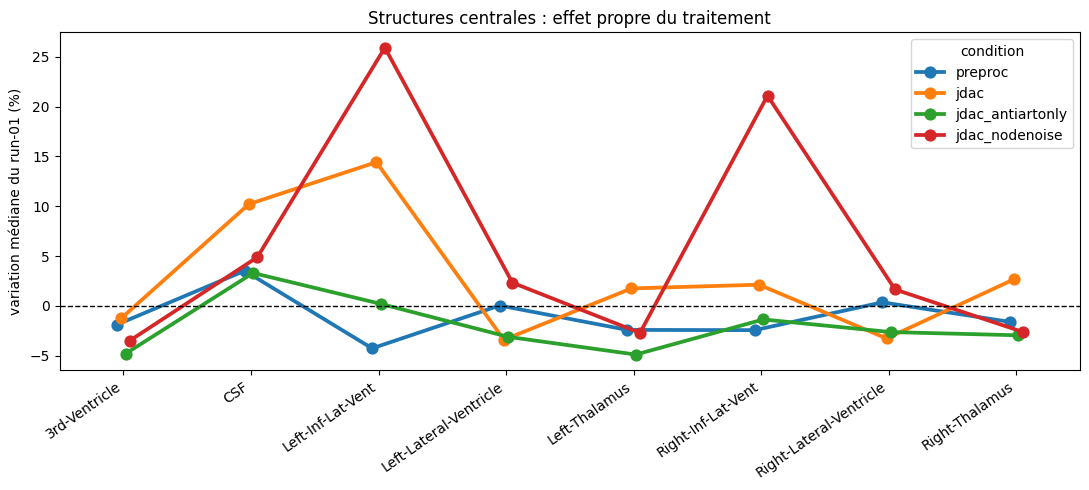

In [8]:
central = [
    "3rd-Ventricle", "Left-Thalamus", "Right-Thalamus",
    "Left-Lateral-Ventricle", "Right-Lateral-Ventricle",
    "Left-Inf-Lat-Vent", "Right-Inf-Lat-Vent", "CSF"
]
central = [m for m in central if m in anat]
central_a = a[a["measure"].isin(central)].copy()
display(central_a.sort_values(["measure","condition"])
        .loc[:, ["condition","measure","baseline_mm3","delta_median_mm3","delta_pct","p_fdr"]]
        .round({"baseline_mm3":0,"delta_median_mm3":0,"delta_pct":2,"p_fdr":4}))
if len(central_a):
    plt.figure(figsize=(11, 5))
    sns.pointplot(data=central_a, x="measure", y="delta_pct",
                  hue="condition", dodge=True)
    plt.axhline(0, color="black", ls="--", lw=1)
    plt.ylabel("variation médiane du run-01 (%)")
    plt.xlabel(""); plt.xticks(rotation=35, ha="right")
    plt.title("Structures centrales : effet propre du traitement")
    plt.tight_layout(); plt.show()

## Synthèse automatique

Résumé chiffré tiré directement des tables ci-dessus, pour relire le notebook sans recalcul manuel. Aucune valeur n'est saisie à la main.

In [9]:
lignes = []
for condition in CONDITIONS[1:]:
    aa = a[a["condition"]==condition]
    top = aa.loc[aa["delta_pct"].abs().idxmax()] if len(aa) else None
    frac = summary_b.loc[condition, "fraction_amelioree"] if condition in summary_b.index else np.nan
    nsig = int((c[c["condition"]==condition]["p_fdr"] < 0.05).sum())
    lignes.append({
        "condition": condition,
        "run-01 : structure la plus déplacée": f"{top['measure']} ({top['delta_pct']:+.1f} %)" if top is not None else "",
        "récupération : fraction améliorée": round(frac, 3) if frac == frac else np.nan,
        "mvt résiduel : n mesures liées à Agitation (FDR<0.05)": nsig,
    })
synth = pd.DataFrame(lignes).set_index("condition")
display(synth)
nsig_brut = int((c[c["condition"]=="brut"]["p_fdr"] < 0.05).sum())
print(f"Référence : sur le brut, {nsig_brut} volumes anatomiques sont liés à Agitation (FDR<0.05).")

,run-01 : structure la plus déplacée,récupération : fraction améliorée,mvt résiduel : n mesures liées à Agitation (FDR<0.05)
condition,,,
preproc,lhCortexVol (-4.4 %),0.475,35
jdac,Right-Cerebellum-White-Matter (+15.2 %),0.321,39
jdac_antiartonly,rhCortexVol (-8.3 %),0.471,35
jdac_nodenoise,Left-Inf-Lat-Vent (+25.9 %),0.459,40


Référence : sur le brut, 31 volumes anatomiques sont liés à Agitation (FDR<0.05).


## Conclusion à remplir après exécution

- **Stabilité du run-01 :** quelles structures anatomiques sont déplacées sans mouvement, et de combien en mm³ / % ?
- **Qualité :** un traitement crée-t-il des trous de surface ou des hypointensités (section A-bis) ?
- **Récupération :** quelles conditions rapprochent réellement les runs bougés de la référence, structure par structure ?
- **Mouvement résiduel :** combien de volumes restent liés à Agitation après FDR, et lesquels ?
- **Zone centrale :** le changement est-il un contraste visuel, un volume différent ou un label différent ?

Aucune amélioration globale ne sera appelée « restauration anatomique » sans cohérence entre ces lectures.